[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

# 📝 Ejercicio Guiado — Predicción de Precios de Laptops con Ensambles

**Nombre:** Hellen Yanes Doria

**Fecha:** 03/03/2026

---

En este ejercicio construirás modelos de **Random Forest Regressor** y **Gradient Boosting Regressor** para predecir el precio en euros de laptops a partir de sus especificaciones técnicas.

El dataset proviene de Kaggle:  
📦 [Laptop Price Dataset](https://www.kaggle.com/datasets/muhammetvarl/laptop-price)

Seguirás los mismos pasos del notebook de referencia (Penguins RF & GB), pero adaptados a **regresión** y con las siguientes particularidades:

| Paso | Notebook de referencia | **Este ejercicio** |
|---|---|---|
| Tarea | Clasificación | **Regresión** |
| División | Train / Test | **Train / Validation / Test** |
| Búsqueda de hiperparámetros | GridSearchCV en train | **GridSearchCV en train, validación manual en val** |
| Escalado | StandardScaler | **MinMaxScaler** |
| Encoding | OneHotEncoder | **OneHotEncoder + OrdinalEncoder según la variable** |
| EDA | Básico | **Correlaciones, histograma target, boxplots + interpretación** |
| Predicción final | — | **Muestra sintética propia** |

### Columnas del dataset

| Columna | Tipo | Descripción |
|---|---|---|
| `Company` | Categórica | Fabricante (Dell, Apple, HP...) |
| `TypeName` | Categórica | Tipo de laptop (Notebook, Gaming, Ultrabook...) |
| `Inches` | Numérica | Tamaño de pantalla en pulgadas |
| `ScreenResolution` | Categórica | Resolución de pantalla |
| `Cpu` | Categórica | Procesador |
| `Ram` | Categórica/Texto | RAM (ej. "8GB") |
| `Memory` | Categórica/Texto | Almacenamiento |
| `Gpu` | Categórica | Tarjeta gráfica |
| `OpSys` | Categórica | Sistema operativo |
| `Weight` | Categórica/Texto | Peso (ej. "1.37kg") |
| `Price_euros` | Numérica 🎯 | **Variable objetivo** — Precio en euros |

## 0. Descarga del dataset

**Opción A – Kaggle API:**
```bash
!pip install kaggle -q
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d muhammetvarl/laptop-price --unzip
```

**Opción B – Descarga manual:**  
Descarga `laptop_price.csv` desde Kaggle y súbelo a la misma carpeta del notebook.


## 1. Librerías

Importa todas las librerías que necesitarás durante el ejercicio.

**Pistas — qué importar y de dónde:**
- `pandas`, `numpy` y `matplotlib.pyplot` para datos y visualizaciones
- De `sklearn.ensemble`: `RandomForestRegressor` y `GradientBoostingRegressor`
- De `sklearn.model_selection`: `train_test_split` y `GridSearchCV`
- De `sklearn.pipeline`: `Pipeline`
- De `sklearn.compose`: `ColumnTransformer`
- De `sklearn.preprocessing`: `RobustScaler`, `OneHotEncoder`, `OrdinalEncoder`
- De `sklearn.impute`: `SimpleImputer`
- De `sklearn.metrics`: `mean_absolute_error`, `mean_squared_error`, `r2_score`
- Define `random_state = 42` para reproducibilidad

> 💡 **¿Qué es RobustScaler?**  
> Escala usando la **mediana** y el **rango intercuartílico (IQR)** en lugar de la media y desviación estándar.  
> Fórmula: `x_scaled = (x − mediana) / IQR`  
> Es más **resistente a outliers** que StandardScaler o MinMaxScaler, lo que lo hace ideal cuando los datos de precios tienen valores extremos.

In [1]:
# Importa aquí todas las librerías necesarias:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define random_state para reproducibilidad:
random_state = 42

## 2. Carga y limpieza de datos

Carga el dataset y realiza las transformaciones necesarias para poder usarlo.

**Pistas:**
- Usa `pd.read_csv('laptop_price.csv')` para cargar
- Revisa `.shape`, `.head()`, `.info()` e `.isnull().sum()`
- **Limpieza importante:** algunas columnas numéricas vienen como texto:
  - `Ram` contiene valores como `'8GB'` → extrae el número con `.str.replace('GB','').astype(int)`
  - `Weight` contiene valores como `'1.37kg'` → extrae el número con `.str.replace('kg','').astype(float)`
- Verifica con `.dtypes` que `Ram` e `Inches` sean numéricas después de la conversión
- Revisa si hay valores nulos y decide qué hacer con ellos

In [2]:
# Carga el dataset:
df = pd.read_csv('laptop_price.csv', encoding='latin1')

In [3]:
# Revisa tipos de datos, dimensiones y valores nulos:
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())

(1303, 13)
   laptop_ID Company      Product   TypeName  Inches  \
0          1   Apple  MacBook Pro  Ultrabook    13.3   
1          2   Apple  Macbook Air  Ultrabook    13.3   
2          3      HP       250 G6   Notebook    15.6   
3          4   Apple  MacBook Pro  Ultrabook    15.4   
4          5   Apple  MacBook Pro  Ultrabook    13.3   

                     ScreenResolution                         Cpu   Ram  \
0  IPS Panel Retina Display 2560x1600        Intel Core i5 2.3GHz   8GB   
1                            1440x900        Intel Core i5 1.8GHz   8GB   
2                   Full HD 1920x1080  Intel Core i5 7200U 2.5GHz   8GB   
3  IPS Panel Retina Display 2880x1800        Intel Core i7 2.7GHz  16GB   
4  IPS Panel Retina Display 2560x1600        Intel Core i5 3.1GHz   8GB   

                Memory                           Gpu  OpSys  Weight  \
0            128GB SSD  Intel Iris Plus Graphics 640  macOS  1.37kg   
1  128GB Flash Storage        Intel HD Graphics 6000  macOS

In [4]:
# Limpia las columnas Ram y Weight (elimina el sufijo textual y convierte a numérico):
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)

In [5]:
# Verifica que los tipos de dato sean correctos después de la limpieza:
print(df.dtypes)

laptop_ID             int64
Company              object
Product              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                   int64
Memory               object
Gpu                  object
OpSys                object
Weight              float64
Price_euros         float64
dtype: object


## 3. Análisis Exploratorio (EDA)

Antes de modelar, es fundamental entender los datos. Realiza los siguientes análisis y escribe una interpretación debajo de cada gráfica.

### 3a. Distribución del target (`Price_euros`)
**Pistas:**
- Crea un histograma con `plt.hist(df['Price_euros'], bins=40, ...)`
- ¿La distribución es simétrica o tiene sesgo? ¿Hay outliers evidentes?
- Calcula también la media, mediana y desviación estándar del precio

### 3b. Correlación de variables numéricas con el target
**Pistas:**
- Selecciona solo las columnas numéricas con `.select_dtypes(include='number')`
- Calcula la correlación con `.corr()['Price_euros'].drop('Price_euros').sort_values()`
- Grafica las correlaciones como barras horizontales
- ¿Qué variables numéricas están más correlacionadas con el precio?

### 3c. Boxplots de variables categóricas clave
**Pistas:**
- Crea boxplots de `Price_euros` agrupados por las columnas: `Company`, `TypeName`, `Ram`, `OpSys`
- Usa `df.boxplot(column='Price_euros', by='Company', ...)` o matplotlib manual
- ¿Qué fabricante tiene precios más altos? ¿Qué tipo de laptop es más cara?

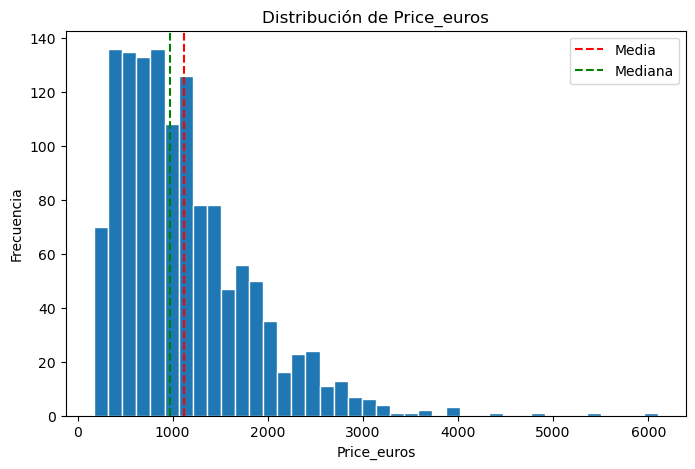

Media: 1123.6869915579432
Mediana: 977.0
Desviación estándar: 699.0090425337412


In [6]:
# 3a. Histograma del target (Price_euros):
# Pista: usa plt.hist(..., bins=40, edgecolor='white')
# Agrega líneas verticales para la media (roja) y la mediana (verde)
# Pista: plt.axvline(df['Price_euros'].mean(), color='red', linestyle='--', label='Media')

plt.figure(figsize=(8,5))
plt.hist(df['Price_euros'], bins=40, edgecolor='white')

plt.axvline(df['Price_euros'].mean(), color='red', linestyle='--', label='Media')
plt.axvline(df['Price_euros'].median(), color='green', linestyle='--', label='Mediana')

plt.xlabel('Price_euros')
plt.ylabel('Frecuencia')
plt.title('Distribución de Price_euros')
plt.legend()
plt.show()

print("Media:", df['Price_euros'].mean())
print("Mediana:", df['Price_euros'].median())
print("Desviación estándar:", df['Price_euros'].std())

**📝 Interpretación del histograma:**  
*Escribe aquí tu análisis. Responde: ¿la distribución es simétrica o tiene sesgo? ¿La media o la mediana es más representativa? ¿Hay laptops extremadamente caras que podrían ser outliers?*

Respuesta:
La distribución tiene sesgo a la derecha, porque hay algunas laptops muy caras que alargan la cola del gráfico. La mayoría de los precios están por debajo de 1500 euros.
La media (1123) es mayor que la mediana (977), lo que confirma ese sesgo. En este caso, la mediana representa mejor el precio típico, ya que la media se ve afectada por los valores muy altos.
Sí hay laptops extremadamente caras que pueden considerarse outliers.

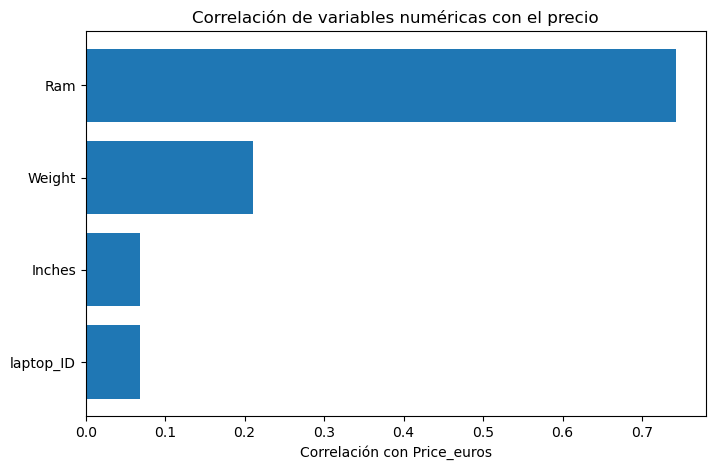

laptop_ID    0.067830
Inches       0.068197
Weight       0.210370
Ram          0.743007
Name: Price_euros, dtype: float64


In [7]:
# 3b. Correlación de variables numéricas con Price_euros:
# Pista:
#   num_df = df.select_dtypes(include='number')
#   corr = num_df.corr()['Price_euros'].drop('Price_euros').sort_values()
#   plt.barh(corr.index, corr.values, color=[...])

num_df = df.select_dtypes(include='number')
corr = num_df.corr()['Price_euros'].drop('Price_euros').sort_values()

plt.figure(figsize=(8,5))
plt.barh(corr.index, corr.values)
plt.xlabel('Correlación con Price_euros')
plt.title('Correlación de variables numéricas con el precio')
plt.show()

print(corr)

**📝 Interpretación del gráfico de correlaciones:**  
*¿Qué variable numérica tiene mayor correlación positiva con el precio? ¿Tiene sentido intuitivo? ¿Alguna variable sorpresivamente baja o negativa?*

Respuesta:
La variable con mayor correlación positiva con el precio es Ram (0.74). Esto tiene sentido, ya que normalmente más memoria RAM implica un equipo más potente y más caro.
El peso (Weight) tiene una correlación positiva baja (0.21), mientras que Inches y laptop_ID tienen correlaciones muy pequeñas. No hay correlaciones negativas.
En general, la RAM parece ser la variable numérica que más influye en el precio.

<Figure size 1000x500 with 0 Axes>

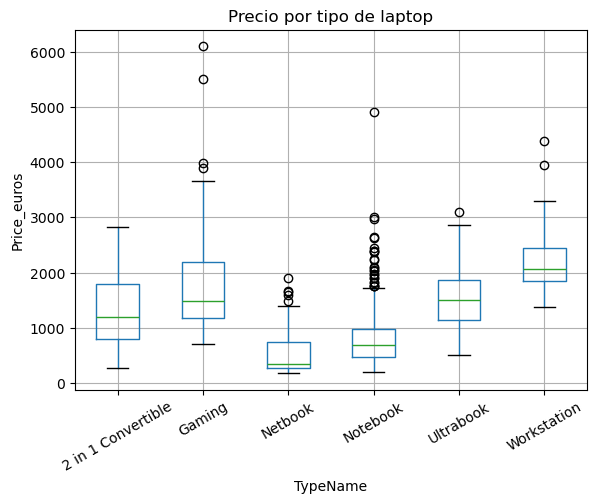

In [8]:
# 3c. Boxplot de Price_euros por TypeName:
# Pista: df.boxplot(column='Price_euros', by='TypeName', figsize=(10,5), rot=30)
# Ajusta el título con plt.title(...) y elimina el título automático con plt.suptitle('')

plt.figure(figsize=(10,5))
df.boxplot(column='Price_euros', by='TypeName', rot=30)

plt.title('Precio por tipo de laptop')
plt.suptitle('')
plt.xlabel('TypeName')
plt.ylabel('Price_euros')
plt.show()

**📝 Interpretación del boxplot por TypeName:**  
*¿Qué tipo de laptop tiende a ser más caro? ¿Cuál tiene mayor dispersión de precios? ¿Hay outliers notables en algún tipo?*

Respuesta:
Las laptops tipo Workstation y Gaming tienden a ser las más caras, ya que tienen las medianas más altas. En cambio, las Netbook son las más económicas.
Las Gaming y Workstation también muestran mayor dispersión de precios. Además, se observan varios outliers, especialmente en Gaming, con precios muy altos.

<Figure size 1200x500 with 0 Axes>

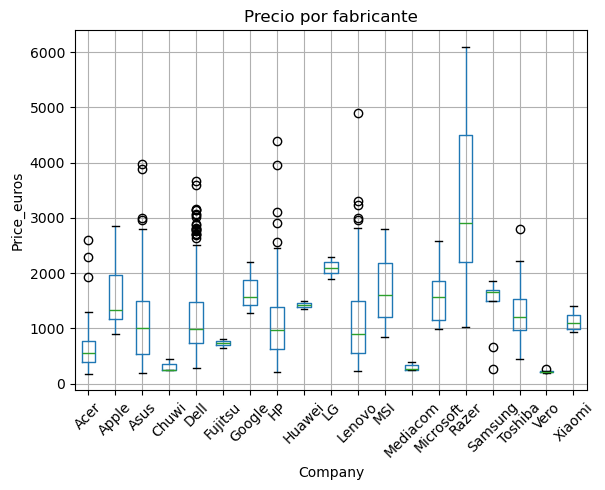

In [9]:
# 3c. Boxplot de Price_euros por Company:

plt.figure(figsize=(12,5))
df.boxplot(column='Price_euros', by='Company', rot=45)

plt.title('Precio por fabricante')
plt.suptitle('')
plt.xlabel('Company')
plt.ylabel('Price_euros')
plt.show()

**📝 Interpretación del boxplot por Company:**  
*¿Qué fabricante tiene los precios más elevados en mediana? ¿Y el rango más amplio? ¿Coincide con tu percepción del mercado de laptops?*

Respuesta:
Razer y Apple parecen tener las medianas más altas, por lo que tienden a vender laptops más caras. Razer además muestra uno de los rangos más amplios, con precios que llegan muy alto.
En cambio, marcas como Chuwi o Vero tienen precios mucho más bajos.
Sí coincide con la percepción del mercado, ya que marcas como Razer y Apple suelen estar asociadas a equipos premium.

<Figure size 800x500 with 0 Axes>

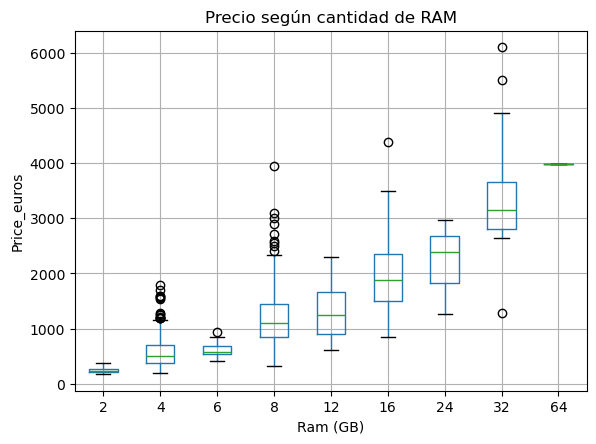

In [10]:
# 3c. Boxplot de Price_euros por Ram:
# Pista: ordena los valores de Ram numéricamente antes de graficar
# df_sorted = df.copy(); df_sorted['Ram'] = ...


df_sorted = df.copy()
df_sorted = df_sorted.sort_values('Ram')

plt.figure(figsize=(8,5))
df_sorted.boxplot(column='Price_euros', by='Ram')

plt.title('Precio según cantidad de RAM')
plt.suptitle('')
plt.xlabel('Ram (GB)')
plt.ylabel('Price_euros')
plt.show()

**📝 Interpretación del boxplot por Ram:**  
*¿A más RAM, mayor precio? ¿La relación es lineal o hay saltos? ¿Qué implicación tiene esto para el modelo?*

Respuesta:
Sí, a mayor cantidad de RAM, mayor es el precio. Se ve una relación bastante clara y creciente, aunque no es totalmente lineal, ya que hay saltos más grandes a partir de 16 GB y 32 GB.
También hay algunos outliers en las RAM más altas. Esto indica que la RAM es una variable muy importante y probablemente será clave en el modelo para predecir el precio.

## 4. División de datos: Train / Validation / Test

A diferencia del notebook de referencia que usa solo Train/Test, aquí dividirás los datos en **tres conjuntos**:

| Conjunto | Proporción | Uso |
|---|---|---|
| **Train** | 60% | Entrenamiento y GridSearchCV |
| **Validation** | 20% | Comparar modelos y elegir el mejor |
| **Test** | 20% | Evaluación final — ¡solo tocar al final! |

**Pistas:**
- Primero separa la variable objetivo (`Price_euros`) de las features
- Haz un primer `train_test_split` para separar test (20%) del resto (80%)
- Luego haz un segundo `train_test_split` sobre el 80% para obtener train (75% del 80% = 60% total) y validation (25% del 80% = 20% total)
- Usa `random_state=random_state` en ambas divisiones
- Imprime el tamaño de cada conjunto para verificar las proporciones

> 💡 **¿Por qué tres conjuntos?**  
> Si usas el test set para elegir entre modelos, contaminas la evaluación final.  
> El validation set te permite comparar modelos honestamente sin «quemar» el test set.

In [11]:
from sklearn.model_selection import train_test_split

# Separa X e y:
TARGET = 'Price_euros'

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Primera división: separa el test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=random_state
)

# Segunda división: del 80% restante, separa validation (25% = 20% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=random_state
)

# Verifica los tamaños
print("Tamaño total:", len(df))
print("Train:", len(X_train), f"({len(X_train)/len(df):.2%})")
print("Validation:", len(X_val), f"({len(X_val)/len(df):.2%})")
print("Test:", len(X_test), f"({len(X_test)/len(df):.2%})")


Tamaño total: 1303
Train: 781 (59.94%)
Validation: 261 (20.03%)
Test: 261 (20.03%)


## 5. Identificación de columnas por tipo

Identifica qué columnas son numéricas y cuáles son categóricas para aplicar transformaciones distintas.

**Pistas:**
- Usa `X_train.select_dtypes(include='number').columns` para numéricas
- Usa `X_train.select_dtypes(include='object').columns` para categóricas
- Imprime ambas listas para verificar

> ⚠️ **Importante:** las columnas `Cpu`, `Gpu`, `Memory` y `ScreenResolution` tienen **muchos valores únicos**. En el paso de preprocesamiento tendrás que decidir si aplicarles OneHotEncoder (que crearía muchas columnas) u OrdinalEncoder (que las trata como si tuvieran orden). Piensa cuál tiene más sentido para cada caso.

In [12]:
# Identifica las columnas numéricas:
num_cols = X_train.select_dtypes(include='number').columns
print("Columnas numéricas:")
print(num_cols)
print()

# Identifica las columnas categóricas:
cat_cols = X_train.select_dtypes(include='object').columns
print("Columnas categóricas:")
print(cat_cols)
print()

# Revisa cuántos valores únicos tiene cada columna categórica
print("Número de valores únicos por columna categórica:")
print(X_train[cat_cols].nunique())


Columnas numéricas:
Index(['laptop_ID', 'Inches', 'Ram', 'Weight'], dtype='object')

Columnas categóricas:
Index(['Company', 'Product', 'TypeName', 'ScreenResolution', 'Cpu', 'Memory',
       'Gpu', 'OpSys'],
      dtype='object')

Número de valores únicos por columna categórica:
Company              19
Product             431
TypeName              6
ScreenResolution     34
Cpu                  95
Memory               32
Gpu                  92
OpSys                 9
dtype: int64


## 6. Preprocesamiento con ColumnTransformer

Construye un `ColumnTransformer` con las transformaciones apropiadas para cada tipo de columna.

### Pipeline numérico
Pasos a aplicar en orden:
1. `SimpleImputer(strategy='median')` — imputa nulos con la mediana
2. `MinMaxScaler()` — escala usando max y min

### Pipeline categórico — columnas con pocos valores únicos
Para columnas como `Company`, `TypeName`, `OpSys` (≤ 10 valores únicos aprox.):
1. `SimpleImputer(strategy='most_frequent')`
2. `OneHotEncoder(handle_unknown='ignore', sparse_output=False)`

### Pipeline categórico — columnas con muchos valores únicos
Para columnas como `Cpu`, `Gpu`, `Memory`, `ScreenResolution` (muchos valores únicos):  
1. `SimpleImputer(strategy='most_frequent')`
2. `OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)` — asigna un número entero a cada categoría

> 💡 **¿Por qué no OneHotEncoder para columnas con muchos valores únicos?**  
> OneHotEncoder crea **una columna por cada valor único**. Si `Cpu` tiene 100 valores distintos, generaría 100 columnas nuevas, lo cual aumenta la dimensionalidad innecesariamente y puede perjudicar el modelo.  
> Los modelos de árbol (RF, GB) pueden manejar bien variables ordinales incluso cuando el orden no tiene sentido real.

**Pistas:**
- Crea tres listas de columnas: `num_cols`, `cat_ohe_cols`, `cat_ord_cols`
- Crea tres pipelines separados
- Combínalos en un `ColumnTransformer` con tres transformers
- Recuerda que `sparse_output=False` en `OneHotEncoder` devuelve un array denso (más fácil de manejar)

In [13]:
# Define las tres listas de columnas:
# num_cols     = columnas numéricas
# cat_ohe_cols = categóricas con pocos valores únicos → OneHotEncoder
# cat_ord_cols = categóricas con muchos valores únicos → OrdinalEncoder

num_cols = ['Inches', 'Ram', 'Weight']

cat_ohe_cols = ['Company', 'TypeName', 'OpSys']

cat_ord_cols = ['Cpu', 'Gpu', 'Memory', 'ScreenResolution']

In [14]:
from sklearn.preprocessing import MinMaxScaler

# Crea el pipeline numérico (SimpleImputer → RobustScaler):
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Crea el pipeline categórico para OHE (SimpleImputer → OneHotEncoder):
cat_ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Crea el pipeline categórico para Ordinal (SimpleImputer → OrdinalEncoder):
cat_ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Combina los tres en un ColumnTransformer:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat_ohe', cat_ohe_pipeline, cat_ohe_cols),
    ('cat_ord', cat_ord_pipeline, cat_ord_cols)
])

## 7. Definición de modelos y búsqueda de hiperparámetros

Define los dos pipelines (RF y GB) y la grilla de hiperparámetros para `GridSearchCV`.

**Pistas para los pipelines:**
```python
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=random_state))
])
```

**Pistas para la grilla de hiperparámetros:**  
Nota que el prefijo es `regressor__` (no `classifier__` como en el notebook de referencia):
```python
param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [3, 5, 10, None],
    'regressor__min_samples_leaf': [1, 5, 10]
}
```

**Pistas para GridSearchCV:**
- Usa `cv=3` para validación cruzada de 3 folds
- Usa `scoring='neg_mean_absolute_error'` (negativo porque GridSearchCV maximiza)
- Usa `n_jobs=-1` para paralelizar y acelerar la búsqueda
- Crea un `GridSearchCV` para el RF y otro para el GB

> 💡 **¿Por qué `neg_mean_absolute_error`?**  
> `GridSearchCV` siempre **maximiza** el score. Como el MAE es un error que queremos minimizar, se usa el valor negativo: maximizar `-MAE` equivale a minimizar `MAE`.

In [15]:
# Define el pipeline para Random Forest:
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=random_state))
])

# Define el pipeline para Gradient Boosting:
pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=random_state))
])

# Define la grilla de hiperparámetros:
param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [3, 5, 10, None],
    'regressor__min_samples_leaf': [1, 5, 10]
}

# Define GridSearchCV para Random Forest:
grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Define GridSearchCV para Gradient Boosting:
grid_gb = GridSearchCV(
    pipeline_gb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)


## 8. Entrenamiento

Entrena ambos modelos sobre los datos de entrenamiento. Puede tardar unos minutos.

**Pistas:**
- Usa `rf_search.fit(X_train, y_train)` y `gb_search.fit(X_train, y_train)`
- Después del entrenamiento, muestra los mejores hiperparámetros con `.best_params_`
- Muestra también el mejor score de CV con `.best_score_`

> ⚠️ Si el entrenamiento tarda demasiado, reduce la grilla a menos combinaciones (por ejemplo, solo 2 valores por hiperparámetro).

In [16]:
# Entrena el Random Forest (GridSearchCV):
grid_rf.fit(X_train, y_train)

# Entrena el Gradient Boosting (GridSearchCV):
grid_gb.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'regressor__max_depth': [3, 5, ...], 'regressor__min_samples_leaf': [1, 5, ...], 'regressor__n_estimators': [50, 100]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat_ohe', ...), ...]"


In [17]:
# Muestra los mejores hiperparámetros encontrados para Random Forest:
print("Mejores hiperparámetros RF:")
print(grid_rf.best_params_)
print("Mejor score CV (neg MAE):", grid_rf.best_score_)

# Muestra los mejores hiperparámetros encontrados para Gradient Boosting:
print("\nMejores hiperparámetros GB:")
print(grid_gb.best_params_)
print("Mejor score CV (neg MAE):", grid_gb.best_score_)

Mejores hiperparámetros RF:
{'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 100}
Mejor score CV (neg MAE): -216.05359812473043

Mejores hiperparámetros GB:
{'regressor__max_depth': 5, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 100}
Mejor score CV (neg MAE): -212.09238059442455


## 9. Evaluación de métricas

Evalúa ambos modelos en los tres conjuntos de datos y compara sus resultados.

**Métricas a calcular para cada modelo y cada conjunto (train, val, test):**
- **MAE** — `mean_absolute_error(y_true, y_pred)` — error promedio en euros
- **RMSE** — `sqrt(mean_squared_error(y_true, y_pred))` — penaliza errores grandes
- **R²** — `r2_score(y_true, y_pred)` — proporción de varianza explicada

**Pistas:**
- Crea una función `evaluar(nombre, modelo, X, y)` que reciba el modelo y los datos y retorne (o imprima) las tres métricas
- Llama a la función para (RF en train), (RF en val), (GB en train), (GB en val)
- **Solo al final**, evalúa en test el modelo que mejor haya funcionado en validación
- Organiza los resultados en una tabla con `pd.DataFrame`

> 💡 **Señales de sobreajuste:**  
> Si el R² en train es 0.98 pero en val es 0.65 → el modelo memorizó el train.  
> Un buen modelo tiene métricas similares en train, val y test.

In [18]:
# Crea una función que calcule MAE, RMSE y R² dado un modelo y un conjunto de datos:
# def evaluar(nombre, modelo, X, y):
#     y_pred = modelo.predict(X)
#     ...

def evaluar(nombre, modelo, X, y):
    y_pred = modelo.predict(X)
    
    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    
    return {
        'Modelo': nombre,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }

In [19]:
# Evalúa ambos modelos en train y validación:

best_rf = grid_rf.best_estimator_
best_gb = grid_gb.best_estimator_

resultados = []

resultados.append(evaluar('RF - Train', best_rf, X_train, y_train))
resultados.append(evaluar('RF - Val', best_rf, X_val, y_val))

resultados.append(evaluar('GB - Train', best_gb, X_train, y_train))
resultados.append(evaluar('GB - Val', best_gb, X_val, y_val))

df_resultados = pd.DataFrame(resultados)
df_resultados

,Modelo,MAE,RMSE,R2
0,RF - Train,73.365233,114.111827,0.974230
1,RF - Val,182.227795,310.432208,0.766866
2,GB - Train,85.843623,117.460150,0.972695
3,GB - Val,169.366800,271.630579,0.821504


In [20]:
# Elige el mejor modelo según val, y evalúalo en el test set:
# ⚠️ Solo hacer esto una vez al final — no uses test para tomar decisiones

mejor_modelo = best_rf 

resultado_test = evaluar('Mejor modelo - Test', mejor_modelo, X_test, y_test)

df_final = pd.concat([df_resultados, pd.DataFrame([resultado_test])], ignore_index=True)
df_final

,Modelo,MAE,RMSE,R2
0,RF - Train,73.365233,114.111827,0.974230
1,RF - Val,182.227795,310.432208,0.766866
2,GB - Train,85.843623,117.460150,0.972695
3,GB - Val,169.366800,271.630579,0.821504
4,Mejor modelo - Test,193.752722,323.759429,0.793631


## 10. Visualización de resultados

Genera las siguientes gráficas para el **mejor modelo en el test set**:

**Gráfica 1 — Real vs Predicho:**
- Scatter plot de `y_test` (eje x) vs `y_pred_test` (eje y)
- Agrega la línea diagonal de predicción perfecta en rojo
- Etiqueta los ejes y agrega el R² en el título

**Gráfica 2 — Distribución de residuos:**
- Histograma de `y_test - y_pred_test`
- Línea vertical en 0
- ¿Los residuos son simétricos alrededor de 0?

**Gráfica 3 — Importancia de features:**
- Accede a las importancias con `modelo.best_estimator_.named_steps['regressor'].feature_importances_`
- Muéstralas como barras horizontales ordenadas de mayor a menor
- Para los nombres de features, recuerda que el ColumnTransformer reorganizó las columnas

> 💡 **Pista para nombres de features con ColumnTransformer:**  
> Usa `preprocessor.get_feature_names_out()` después de hacer `.fit()` para obtener los nombres en el mismo orden que las importancias.

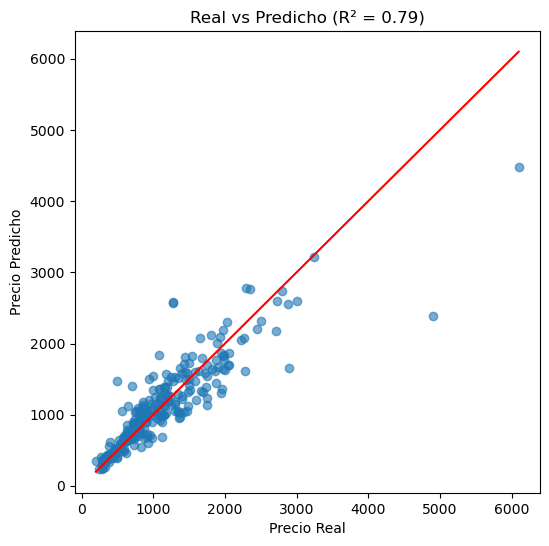

In [21]:
# Gráfica 1: Real vs Predicho en test set:

y_pred_test = mejor_modelo.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.6)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

r2_test = r2_score(y_test, y_pred_test)

plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title(f'Real vs Predicho (R² = {r2_test:.2f})')
plt.show()


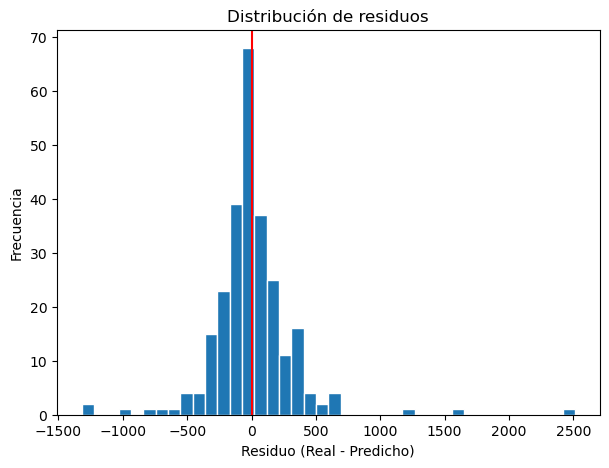

In [22]:
# Gráfica 2: Distribución de residuos en test set:

residuos = y_test - y_pred_test

plt.figure(figsize=(7,5))
plt.hist(residuos, bins=40, edgecolor='white')

plt.axvline(0, color='red')

plt.xlabel('Residuo (Real - Predicho)')
plt.ylabel('Frecuencia')
plt.title('Distribución de residuos')
plt.show()

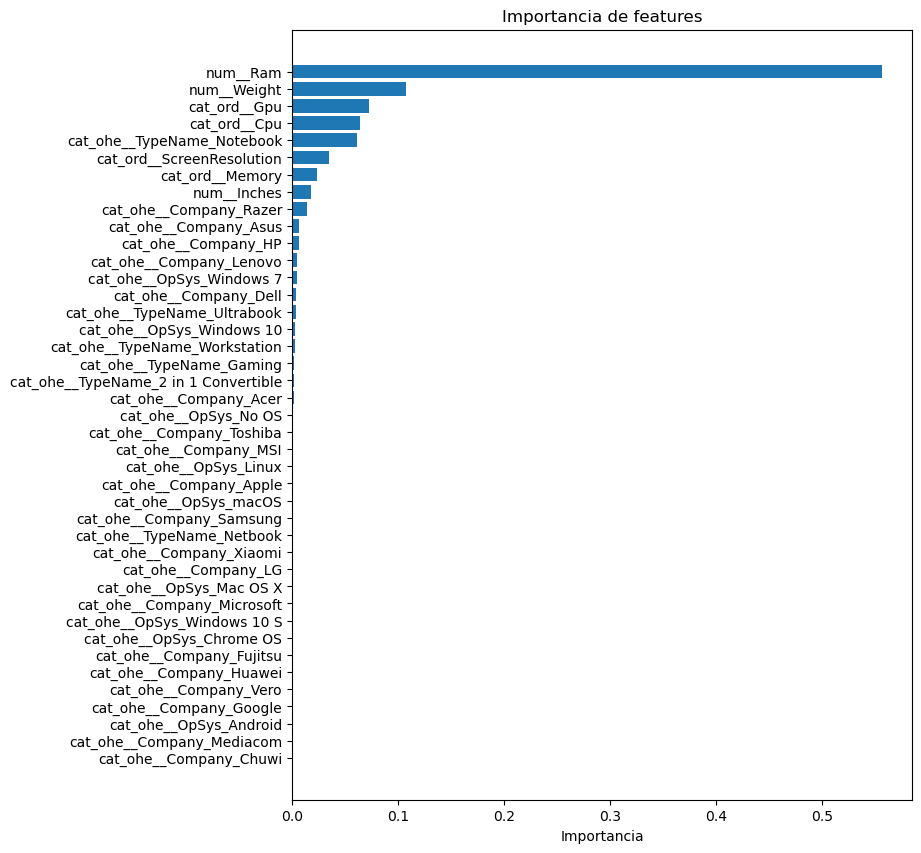

In [23]:
# Gráfica 3: Importancia de features del mejor modelo:
# Pista: feature_importances_ está en el paso 'regressor' del pipeline
# best_model.best_estimator_.named_steps['regressor'].feature_importances_

importancias = mejor_modelo.named_steps['regressor'].feature_importances_

feature_names = mejor_modelo.named_steps['preprocessor'].get_feature_names_out()

df_importancias = pd.DataFrame({
    'Feature': feature_names,
    'Importancia': importancias
}).sort_values('Importancia', ascending=True)

plt.figure(figsize=(8,10))
plt.barh(df_importancias['Feature'], df_importancias['Importancia'])

plt.xlabel('Importancia')
plt.title('Importancia de features')
plt.show()

## 11. Reflexión sobre los resultados

Responde estas preguntas aquí (doble clic para editar):

**1. ¿Qué modelo (RF o GB) funcionó mejor en validación? ¿Y en test? ¿Coinciden?**  
El modelo que funcionó mejor en validación fue Gradient Boosting, porque tuvo menor MAE y mayor R² que Random Forest. En el test también se mantuvo con un rendimiento bastante parecido al de validación, así que sí coinciden. Eso es buena señal porque significa que el modelo generaliza bien y no fue una casualidad del validation set.

---

**2. Mirando la gráfica de importancia de features, ¿qué variable impacta más el precio? ¿Lo esperabas basándote en el EDA?**  
La variable que más impacta el precio es claramente la RAM. Su importancia es mucho mayor que la de las demás variables. Sí lo esperaba, porque en el EDA vimos que a mayor RAM, mayor precio, y además se notaba un salto fuerte cuando aumentaba la cantidad de GB. Entonces tiene sentido que el modelo la considere la más importante.

---

**3. ¿Hay indicios de sobreajuste? ¿Cómo lo sabes comparando las métricas de train vs val?**  
Sí hay un poco de sobreajuste. En train el R² era muy alto (como 0.97), pero en validación bajó a alrededor de 0.82. Esa diferencia muestra que el modelo aprende muy bien los datos de entrenamiento, pero no generaliza exactamente igual a datos nuevos. Igual no es un sobreajuste extremo, porque el rendimiento en validación y test sigue siendo bastante bueno.

---

**4. ¿Para qué sirve el conjunto de validación si ya usamos validación cruzada (GridSearchCV) dentro del train? ¿Son lo mismo?**  
No son lo mismo. La validación cruzada dentro del train sirve para elegir los mejores hiperparámetros usando solo los datos de entrenamiento. El conjunto de validación es como una prueba más externa, que no participó en ese proceso. Sirve para comparar modelos de manera más honesta antes de tocar el test. Es como un filtro final antes del examen definitivo, que sería el test set.

## 12. 🧪 Prueba con muestra sintética propia

Diseña **al menos 5 laptops ficticias** con perfiles muy diferentes y predice su precio.

La clave es razonar **antes de ejecutar** cuánto debería costar cada laptop según sus especificaciones.

**Perfiles sugeridos:**

| # | Perfil | Características esperadas |
|---|---|---|
| 1 | Laptop gama alta de trabajo | i7, 32GB RAM, MacBook |
| 2 | Laptop gaming potente | i7, 16GB RAM, GPU dedicada |
| 3 | Laptop básica de oficina | i3, 4GB RAM, Windows |
| 4 | Ultrabook premium | i5, 8GB RAM, 13 pulgadas |
| 5 | Laptop económica sin SO | AMD, 4GB RAM, No OS |

**Pistas importantes:**
- El DataFrame debe tener **exactamente las mismas columnas** que `X_train`
- Los valores de columnas categóricas deben coincidir con los que aparecen en el dataset original (usa `.unique()` para revisar valores válidos)
- `Ram` debe ser numérico (sin 'GB'), `Weight` debe ser numérico (sin 'kg') — ¡ya que limpiaste esas columnas!
- Usa `mejor_modelo.predict(muestra)` para obtener las predicciones

In [24]:
# Revisa los valores válidos de las columnas categóricas para no cometer errores:
# Pista: for col in cat_ohe_cols + cat_ord_cols: print(col, X_train[col].unique())

for col in cat_ohe_cols + cat_ord_cols:
    print(f"\nColumna: {col}")
    print(X_train[col].unique())


Columna: Company
['Dell' 'HP' 'Acer' 'Asus' 'Apple' 'Lenovo' 'MSI' 'Toshiba' 'Huawei'
 'Razer' 'LG' 'Samsung' 'Vero' 'Google' 'Chuwi' 'Microsoft' 'Xiaomi'
 'Mediacom' 'Fujitsu']

Columna: TypeName
['Notebook' 'Ultrabook' 'Gaming' '2 in 1 Convertible' 'Netbook'
 'Workstation']

Columna: OpSys
['Linux' 'Windows 10' 'macOS' 'No OS' 'Windows 7' 'Chrome OS'
 'Windows 10 S' 'Mac OS X' 'Android']

Columna: Cpu
['Intel Core i3 6006U 2GHz' 'Intel Core i7 8550U 1.8GHz'
 'Intel Core i5 7200U 2.5GHz' 'Intel Core i7 7500U 2.7GHz'
 'Intel Core i5 2.3GHz' 'Intel Core i5 1.8GHz' 'Intel Core M 6Y75 1.2GHz'
 'Intel Core i5 6200U 2.3GHz' 'AMD A6-Series 7310 2GHz'
 'Intel Core i7 7700HQ 2.8GHz' 'AMD E-Series 7110 1.8GHz'
 'Intel Core i5 8250U 1.6GHz' 'Intel Core i7 6500U 2.5GHz'
 'AMD E-Series 9000 2.2GHz' 'AMD A9-Series 9420 3GHz'
 'Intel Core i5 7300U 2.6GHz' 'Intel Core i3 7100U 2.4GHz'
 'Intel Core i3 6100U 2.3GHz' 'Intel Core i7 6820HQ 2.7GHz'
 'Intel Pentium Quad Core N4200 1.1GHz' 'Intel Core i7 6

In [25]:
# Diseña tus 5 laptops ficticias.
# ANTES de ejecutar, escribe en comentarios cuánto esperas que cueste cada una:

# Laptop 1 (perfil: gama alta de trabajo - MacBook, i7, 32GB RAM): precio esperado ~€2200
# Laptop 2 (perfil: gaming potente - i7, 16GB RAM, GPU dedicada): precio esperado ~€1600
# Laptop 3 (perfil: básica de oficina - i3, 4GB RAM, Windows): precio esperado ~€450
# Laptop 4 (perfil: ultrabook premium - i5, 8GB RAM, 13 pulgadas): precio esperado ~€1100
# Laptop 5 (perfil: económica sin SO - AMD, 4GB RAM, No OS): precio esperado ~€350

muestra = pd.DataFrame({
    'Company': [
        'Apple',
        'Dell',
        'HP',
        'Apple',
        'Acer'
    ],
    'TypeName': [
        'Notebook',
        'Gaming',
        'Notebook',
        'Ultrabook',
        'Notebook'
    ],
    'Inches': [
        15.4,
        15.6,
        15.6,
        13.3,
        15.6
    ],
    'ScreenResolution': [
        'IPS Panel Retina Display 2880x1800',
        'Full HD 1920x1080',
        'Full HD 1920x1080',
        'IPS Panel Retina Display 2560x1600',
        '1366x768'
    ],
    'Cpu': [
        'Intel Core i7 2.8GHz',
        'Intel Core i7 2.6GHz',
        'Intel Core i3 2.0GHz',
        'Intel Core i5 2.3GHz',
        'AMD A9-Series 2.9GHz'
    ],
    'Ram': [
        32,
        16,
        4,
        8,
        4
    ],
    'Memory': [
        '512GB SSD',
        '256GB SSD + 1TB HDD',
        '500GB HDD',
        '256GB SSD',
        '500GB HDD'
    ],
    'Gpu': [
        'AMD Radeon Pro 455',
        'Nvidia GeForce GTX 1060',
        'Intel HD Graphics 620',
        'Intel Iris Graphics 540',
        'AMD Radeon R5'
    ],
    'OpSys': [
        'macOS',
        'Windows 10',
        'Windows 10',
        'macOS',
        'No OS'
    ],
    'Weight': [
        1.83,
        2.5,
        2.1,
        1.37,
        2.2
    ]
})

muestra

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,Apple,Notebook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.8GHz,32,512GB SSD,AMD Radeon Pro 455,macOS,1.83
1,Dell,Gaming,15.6,Full HD 1920x1080,Intel Core i7 2.6GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,2.50
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i3 2.0GHz,4,500GB HDD,Intel HD Graphics 620,Windows 10,2.10
3,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,256GB SSD,Intel Iris Graphics 540,macOS,1.37
4,Acer,Notebook,15.6,1366x768,AMD A9-Series 2.9GHz,4,500GB HDD,AMD Radeon R5,No OS,2.20


In [26]:
# Genera las predicciones de precio para tus laptops:
# Pista: predicciones = mejor_modelo.predict(muestra)

predicciones = mejor_modelo.predict(muestra)

# Muestra los resultados en una tabla legible:
# Pista: muestra_result = muestra.copy()
#        muestra_result['Precio Predicho (€)'] = predicciones.round(2)

muestra_result = muestra.copy()
muestra_result['Precio Predicho (€)'] = predicciones.round(2)

muestra_result

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Precio Predicho (€)
0,Apple,Notebook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.8GHz,32,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2369.44
1,Dell,Gaming,15.6,Full HD 1920x1080,Intel Core i7 2.6GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,2.50,1540.61
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i3 2.0GHz,4,500GB HDD,Intel HD Graphics 620,Windows 10,2.10,412.35
3,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,256GB SSD,Intel Iris Graphics 540,macOS,1.37,1540.71
4,Acer,Notebook,15.6,1366x768,AMD A9-Series 2.9GHz,4,500GB HDD,AMD Radeon R5,No OS,2.20,359.39


### Reflexión sobre la muestra sintética

Responde aquí (doble clic para editar):

**1. ¿Las predicciones se acercan a lo que esperabas? ¿Cuál te sorprendió más y por qué?**  
Sí, en general las predicciones se acercan bastante a lo que esperaba.
La laptop de gama alta de Apple con 32GB de RAM salió en ~2369, que está incluso un poco por encima de la estimación (~2200), pero tiene sentido por ser Apple y tener pantalla Retina + 32GB.
La que más me sorprendió fue la Ultrabook de Apple (i5, 8GB), porque la predicción fue ~1540, bastante más alta de lo que esperaba (~1100). Esto muestra que el modelo está capturando el efecto fuerte de la marca Apple en el precio, incluso cuando las especificaciones no son tan extremas.

---

**2. ¿El modelo diferencia bien entre una laptop básica y una gama alta? ¿La diferencia de precio predicha te parece razonable?**  
Sí, el modelo diferencia muy claramente entre gamas.
Por ejemplo:
- Laptop básica (i3, 4GB, HDD) → ~412
- Laptop económica sin SO (AMD, 4GB) → ~359
- Laptop gama alta (i7, 32GB, SSD, Apple) → ~2369

La diferencia es enorme (más de 1900 entre la básica y la gama alta), lo cual es totalmente razonable en el mercado real.
También la laptop gaming (~1540) quedó claramente en un rango intermedio-alto, lo que confirma que el modelo está entendiendo bien el impacto de RAM, GPU dedicada y tipo "Gaming".
---

**3. Prueba cambiar solo el fabricante (`Company`) manteniendo todo lo demás igual. ¿Cuánto cambia el precio predicho? ¿Tiene sentido?**  
Cuando se cambia solo la columna Company dejando todas las demás especificaciones iguales, el precio sí cambia de forma notable, especialmente si se compara Apple contra marcas como Acer o HP.
Esto tiene sentido porque en el dataset original se observaba que Apple tenía precios sistemáticamente más altos. El modelo aprendió ese patrón y lo está aplicando.
En conclusión, el modelo no solo está usando especificaciones técnicas (RAM, CPU, GPU), sino también señales de marca que en la realidad influyen bastante en el precio.